# When standard stats meets a human being: a tennis laboratory

**Question.** How much of the comfortable machinery of simple textbook statistics survives
contact with a process that has (i) *absorbing barriers*, (ii) *serial correlation*, and
(iii) *parameter uncertainty*? Tennis is a fun and (maybe) clean place to ask, because the
bottom of the process really is a Bernoulli trial and everything above it is bookkeeping
we control exactly.

**The set-up.** Player A wins any given point with probability $p$; player B wins with
$1-p$. Under the textbook assumptions the number of points A wins in $n$ points is
*exactly* $\mathrm{Binomial}(n,p)$, and $\hat p$ has standard error $\sqrt{p(1-p)/n}$.

### Failure modes of naive intuition

**1. The aggregation is nonlinear (absorbing barriers).**
Tennis does not count points. It counts *games* (first to 4, win by 2), *sets* (first to 6
games, win by 2, tiebreak at 6-6) and *matches* (best of 3 or 5). Each layer is a stopping
problem with absorbing barriers, and the composition
$f(p) = \mathbb{P}(\text{A wins the match})$ is a violently steep S-curve. **This failure
mode is present even with perfectly i.i.d. points.** 

**2. Points are serially correlated (momentum, the hot hand).**
We let the point-win probability depend on the previous point:

$$p_t = \sigma\!\big(\mathrm{logit}(p) + c + k\,s_{t-1}\big), \qquad s_{t-1}\in\{-1,+1\}$$

The offset $c$ is solved numerically so the *stationary* win probability stays exactly $p$.
That calibration is the whole discipline of the experiment: switching correlation on then
changes the **variance and the path structure without moving the mean**, so anything we
observe is attributable to dependence alone.

**3. $p$ is not a constant.** This is the deepest one, and the one N. Taleb calls *fragility*.
$p$ is estimated, drifts with fatigue, surface, wind, and mood. Since $f$ is strongly
curved, $\mathbb{E}[f(\tilde p)] \neq f(\mathbb{E}[\tilde p])$ by Jensen's inequality. We measure that gap
directly.

### The result we will be able to state precisely

For the order-1 chain with lag-1 autocorrelation $\rho$,

$$\frac{\mathrm{Var}(S_n)}{n\,p(1-p)} \;\longrightarrow\; \frac{1+\rho}{1-\rho}$$

A CLT *still holds* — the chain is geometrically mixing, so the shape converges to a
Gaussian. What fails is the **variance you would have plugged in**. At $\rho=0.5$ your error
bars are too small by a factor of $\sqrt3$ and your 1000 observations are worth 333.
Correlation of this kind does not buy you fat tails; it buys you overconfidence and it costs you money.

In [11]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from tennis_lab import (
    TennisSimulator,
    game_win_probability,
    set_win_probability,
    match_win_probability_iid,
)

SEED = 20260803
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False,
})
C0, C1, C2, C3 = "#1f4e79", "#c0392b", "#e08a1e", "#2e7d5b"

_lgamma = np.vectorize(math.lgamma)

def binom_pmf(n, p, k=None):
    '''Binomial pmf via log-gamma (avoids a scipy dependency).'''
    k = np.arange(n + 1) if k is None else np.asarray(k, dtype=float)
    logp = (_lgamma(n + 1) - _lgamma(k + 1) - _lgamma(n - k + 1)
            + k * np.log(p) + (n - k) * np.log1p(-p))
    return np.exp(logp)

def norm_ppf(q):
    '''Acklam rational approximation to the standard normal quantile function.'''
    a = (-3.969683028665376e+01, 2.209460984245205e+02, -2.759285104469687e+02,
         1.383577518672690e+02, -3.066479806614716e+01, 2.506628277459239e+00)
    b = (-5.447609879822406e+01, 1.615858368580409e+02, -1.556989798598866e+02,
         6.680131188771972e+01, -1.328068155288572e+01)
    c = (-7.784894002430293e-03, -3.223964580411365e-01, -2.400758277161838e+00,
         -2.549732539343734e+00, 4.374664141464968e+00, 2.938163982698783e+00)
    d = (7.784695709041462e-03, 3.224671290700398e-01, 2.445134137142996e+00,
         3.754408661907416e+00)
    q = np.asarray(q, dtype=float)
    out = np.empty_like(q)
    plow, phigh = 0.02425, 1 - 0.02425
    lo, hi = q < plow, q > phigh
    mid = ~(lo | hi)

    def tail(x):
        return (((((c[0]*x + c[1])*x + c[2])*x + c[3])*x + c[4])*x + c[5]) / \
               ((((d[0]*x + d[1])*x + d[2])*x + d[3])*x + 1)

    if lo.any():
        x = np.sqrt(-2 * np.log(q[lo])); out[lo] = tail(x)
    if hi.any():
        x = np.sqrt(-2 * np.log1p(-q[hi])); out[hi] = -tail(x)
    if mid.any():
        u = q[mid] - 0.5; r = u * u
        out[mid] = (((((a[0]*r + a[1])*r + a[2])*r + a[3])*r + a[4])*r + a[5]) * u / \
                   (((((b[0]*r + b[1])*r + b[2])*r + b[3])*r + b[4])*r + 1)
    return out

def run_lengths(path, value=1):
    '''Lengths of maximal runs of `value` in a 1-D 0/1 array.'''
    x = np.asarray(path) == value
    if not x.any():
        return np.array([], dtype=int)
    d = np.diff(np.concatenate(([0], x.view(np.int8), [0])))
    return np.flatnonzero(d == -1) - np.flatnonzero(d == 1)

print("ready")

ready


---
## Part 0 — The baseline: i.i.d. points really are binomial

A sanity check on the machinery. With `k = 0` the simulator emits independent Bernoulli
points, so the count over $n$ points must land exactly on $\mathrm{Binomial}(n,p)$. If this
does not overlay perfectly, nothing downstream is trustworthy.

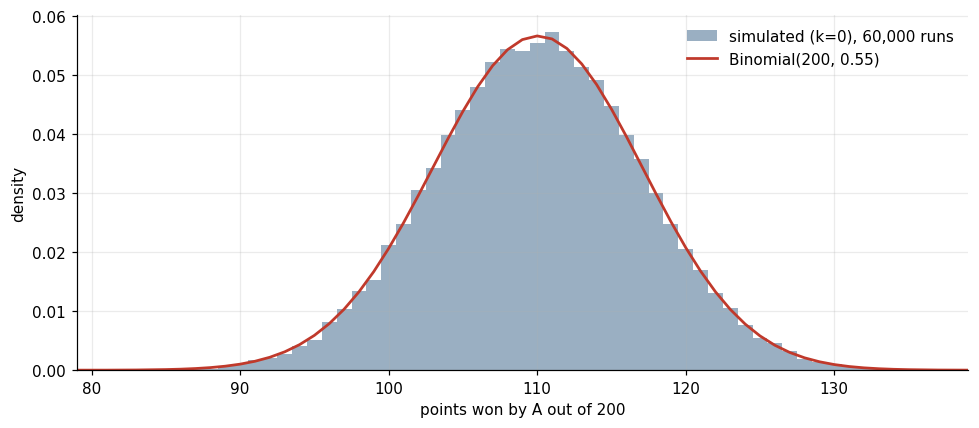

simulated mean  110.0276   binomial mean  110.0000
simulated var    49.2850   binomial var    49.5000


In [12]:
p, n_pts, n_seq = 0.55, 200, 60_000

sim0 = TennisSimulator(p=p, k=0.0, seed=SEED)
counts0 = sim0.simulate_point_sequences(n_seq, n_pts)

k_grid = np.arange(n_pts + 1)
pmf = binom_pmf(n_pts, p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(counts0, bins=np.arange(counts0.min() - .5, counts0.max() + 1.5),
        density=True, color=C0, alpha=.45, label=f"simulated (k=0), {n_seq:,} runs")
ax.plot(k_grid, pmf, color=C1, lw=1.8, label=f"Binomial({n_pts}, {p})")
ax.set_xlim(counts0.min() - 2, counts0.max() + 2)
ax.set_xlabel(f"points won by A out of {n_pts}"); ax.set_ylabel("density")
ax.legend()
plt.tight_layout(); plt.show()

print(f"simulated mean {counts0.mean():9.4f}   binomial mean {n_pts*p:9.4f}")
print(f"simulated var  {counts0.var(ddof=1):9.4f}   binomial var  {n_pts*p*(1-p):9.4f}")

---
## Part 1 — Absorbing barriers alone are already enough to make you wrong

Before even touching independence, it is instructive to look at what the *scoring system* does.
Points are still perfectly i.i.d. — the CLT holds in full — and yet the quantity anyone actually 
cares about, $f(p) = \mathbb{P}(\text{A wins the match})$, behaves nothing like $p$. *They are not 
the same thing!*

Every layer of tennis is a *first-to-N, win-by-2* race: an absorbing-barrier problem. Each
layer takes the edge handed to it and squares it, roughly.

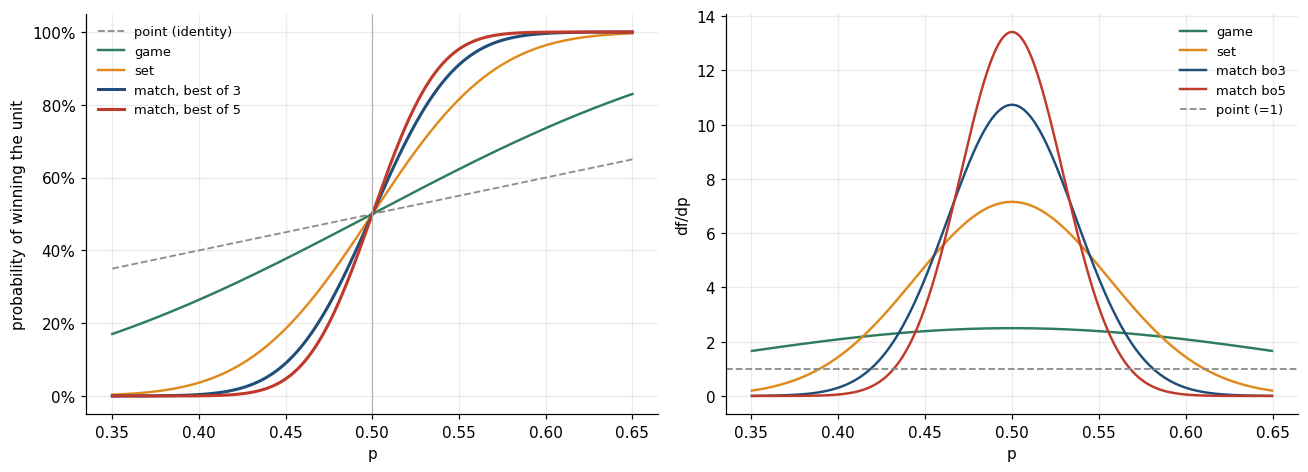

,P(game),P(set),"P(match, bo3)","P(match, bo5)"
p (point),,,,
0.500000,0.5000,0.5000,0.5000,0.5000
0.510000,0.5250,0.5712,0.6060,0.6317
0.520000,0.5499,0.6401,0.7047,0.7493
0.550000,0.6231,0.8150,0.9100,0.9530
0.600000,0.7357,0.9634,0.9961,0.9995


In [13]:
pg = np.linspace(0.35, 0.65, 601)
f_game  = np.array([game_win_probability(x, 4)         for x in pg])
f_set   = np.array([set_win_probability(x)             for x in pg])
f_bo3   = np.array([match_win_probability_iid(x, 3)    for x in pg])
f_bo5   = np.array([match_win_probability_iid(x, 5)    for x in pg])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

ax1.plot(pg, pg,     color="0.55", lw=1.2, ls="--", label="point (identity)")
ax1.plot(pg, f_game, color=C3, lw=1.6, label="game")
ax1.plot(pg, f_set,  color=C2, lw=1.6, label="set")
ax1.plot(pg, f_bo3,  color=C0, lw=2.0, label="match, best of 3")
ax1.plot(pg, f_bo5,  color=C1, lw=2.0, label="match, best of 5")
ax1.axvline(0.5, color="0.7", lw=.8)
ax1.set_xlabel("p")
ax1.set_ylabel("probability of winning the unit")
ax1.legend(loc="upper left", fontsize=8.5)
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))

for arr, lab, col in [(f_game, "game", C3), (f_set, "set", C2),
                      (f_bo3, "match bo3", C0), (f_bo5, "match bo5", C1)]:
    ax2.plot(pg[1:-1], np.gradient(arr, pg)[1:-1], color=col, lw=1.6, label=lab)
ax2.axhline(1, color="0.55", ls="--", lw=1.2, label="point (=1)")
ax2.set_xlabel("p"); ax2.set_ylabel("df/dp")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

rows = []
for x in (0.500, 0.510, 0.520, 0.550, 0.600):
    rows.append({"p (point)": x,
                 "P(game)": game_win_probability(x, 4),
                 "P(set)": set_win_probability(x),
                 "P(match, bo3)": match_win_probability_iid(x, 3),
                 "P(match, bo5)": match_win_probability_iid(x, 5)})
tbl = pd.DataFrame(rows).set_index("p (point)")
display(tbl.style.format("{:.4f}").set_caption("Amplification through the scoring hierarchy"))

A player who wins **51%** of points — a difference no spectator could
perceive, and one you would need thousands of points to detect — wins **60.6%** of best-of-3
matches and **63.2%** of best-of-5 matches. At **55%** of points he wins **91%** of matches.
At 60% they essentially never lose.

Here, the sensitivity panel is the operational statement: at $p=0.5$, $\mathrm{d}f/\mathrm{d}p
= 10.7$ for a best-of-3 match and $13.4$ for best-of-5. **Every unit of error in your
estimate of $p$ is multiplied by more than ten before it reaches the thing you care about.**

*(Aside: this is also exactly why best-of-5 is used for the men's Grand Slams. Longer format
= more absorbing barriers crossed = more amplification = less chance the better player loses.
The format is a variance-reduction device.)*

---
## Part 2 — Switching on correlation

Now we let the previous point matter. First, the analytic characterisation of what each $k$
actually does. Note `stationary_p` stays pinned at 0.55 by construction — the calibration is
working, so the mean is held fixed and only the dependence structure changes.

In [14]:
ks = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]
info = pd.DataFrame([TennisSimulator(p=0.55, k=k).summary() for k in ks])
info = info[["k", "P(win|won last)", "P(win|lost last)", "stationary_p", "rho",
             "variance_inflation", "n_eff_over_n", "mean_run_length_A"]]
display(info.style.format({"k": "{:.2f}", "P(win|won last)": "{:.4f}",
                           "P(win|lost last)": "{:.4f}", "stationary_p": "{:.6f}",
                           "rho": "{:.4f}", "variance_inflation": "{:.3f}",
                           "n_eff_over_n": "{:.3f}", "mean_run_length_A": "{:.2f}"})
        .hide(axis="index")
        .set_caption("What each momentum strength k actually means (p = 0.55)"))

k,P(win|won last),P(win|lost last),stationary_p,rho,variance_inflation,n_eff_over_n,mean_run_length_A
0.00,0.5500,0.5500,0.550000,0.0000,1.000,1.000,2.22
0.25,0.6055,0.4821,0.550000,0.1234,1.281,0.780,2.53
0.50,0.6595,0.4161,0.550000,0.2434,1.644,0.608,2.94
0.75,0.7105,0.3538,0.550000,0.3567,2.109,0.474,3.45
1.00,0.7572,0.2968,0.550000,0.4604,2.707,0.369,4.12
1.50,0.8352,0.2015,0.550000,0.6337,4.460,0.224,6.07


$k=1.0$ is a strong but not absurd hot hand: after winning a point A wins the next 75.7% of
the time, after losing it only 29.7%. His long-run share is still 55%. That configuration
inflates the variance by a factor of **2.71** and reduces the effective sample size to **37%**
of the nominal one.

Now the distribution of points won.

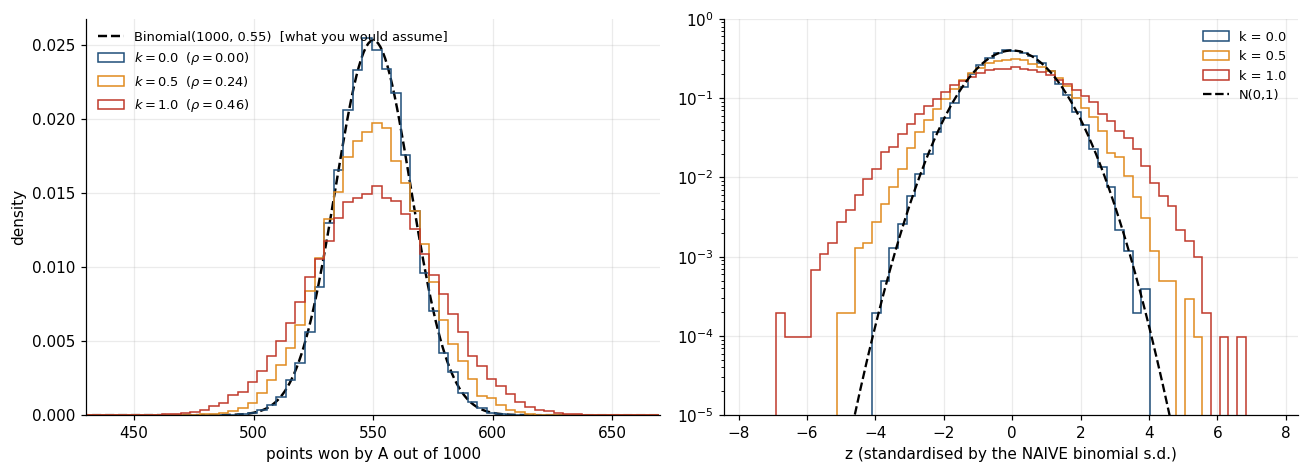

k,rho,mean share,s.d. of count,naive s.d.,P(|z_naive| > 3),P(|z|>3) vs 0.0027
0.00,0.000,0.5501,15.70,15.73,0.0025,0.9x
0.50,0.243,0.5500,20.21,15.73,0.0191,7.1x
1.00,0.460,0.5501,25.82,15.73,0.0665,24.6x


In [15]:
n_pts, n_seq = 1000, 40_000
ks_show = [0.0, 0.5, 1.0]
sims = {k: TennisSimulator(p=0.55, k=k, seed=SEED + i) for i, k in enumerate(ks_show)}
cnts = {k: s.simulate_point_sequences(n_seq, n_pts) for k, s in sims.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
cols = {0.0: C0, 0.5: C2, 1.0: C1}

grid = np.arange(400, 700)
# integer-aligned bins: the counts are discrete, so unaligned bins alias badly
bins = np.arange(429.5, 672, 4)
naive_sd = np.sqrt(n_pts * 0.55 * 0.45)

ax1.plot(grid, binom_pmf(n_pts, 0.55, grid), color="k", lw=1.6, ls="--",
         label=f"Binomial({n_pts}, 0.55)  [what you would assume]")
for k in ks_show:
    ax1.hist(cnts[k], bins=bins, density=True, histtype="step", lw=1.8,
             color=cols[k], label=fr"$k = {k}\;\;(\rho = {sims[k].rho:.2f})$")
ax1.set_xlim(430, 670)
ax1.set_xlabel(f"points won by A out of {n_pts}"); ax1.set_ylabel("density")
ax1.legend(fontsize=8.5, loc = "upper left")

zbins = (bins - n_pts * 0.55) / naive_sd
for k in ks_show:
    z = (cnts[k] - n_pts * 0.55) / naive_sd                       # NAIVE standardisation
    ax2.hist(z, bins=zbins, density=True, histtype="step", lw=1.8, color=cols[k],
             label=f"k = {k}")
zz = np.linspace(-6, 6, 400)
ax2.plot(zz, np.exp(-zz**2 / 2) / np.sqrt(2 * np.pi), color="k", ls="--", lw=1.5,
         label="N(0,1)")
ax2.set_yscale("log"); ax2.set_ylim(1e-5, 1)
ax2.set_xlabel("z (standardised by the NAIVE binomial s.d.)")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

summ = pd.DataFrame({
    "k": ks_show,
    "rho": [sims[k].rho for k in ks_show],
    "mean share": [cnts[k].mean() / n_pts for k in ks_show],
    "s.d. of count": [cnts[k].std(ddof=1) for k in ks_show],
    "naive s.d.": np.sqrt(n_pts * .55 * .45),
    "P(|z_naive| > 3)": [np.mean(np.abs((cnts[k] - n_pts*.55) /
                                        np.sqrt(n_pts*.55*.45)) > 3) for k in ks_show],
})
summ["P(|z|>3) vs 0.0027"] = summ["P(|z_naive| > 3)"] / 0.0027
display(summ.style.format({"k": "{:.2f}", "rho": "{:.3f}", "mean share": "{:.4f}",
                           "s.d. of count": "{:.2f}", "naive s.d.": "{:.2f}",
                           "P(|z_naive| > 3)": "{:.4f}", "P(|z|>3) vs 0.0027": "{:.1f}x"})
        .hide(axis="index"))

The mean is untouched to four decimals. The spread is not. Under the naive binomial
standardisation a "3-sigma" deviation happens about **25 times more often** at $k=1$ than the
0.27% one would budget for — 6.7% of the time rather than 0.27%.

This is the classic mechanism behind risk-model blow-ups, and note how really mild the ingredient
is: no jumps, no regime switch, no exotic distribution. Just "winning makes you a bit more
likely to win again."

Let us check the variance against theory rather than eyeballing it.

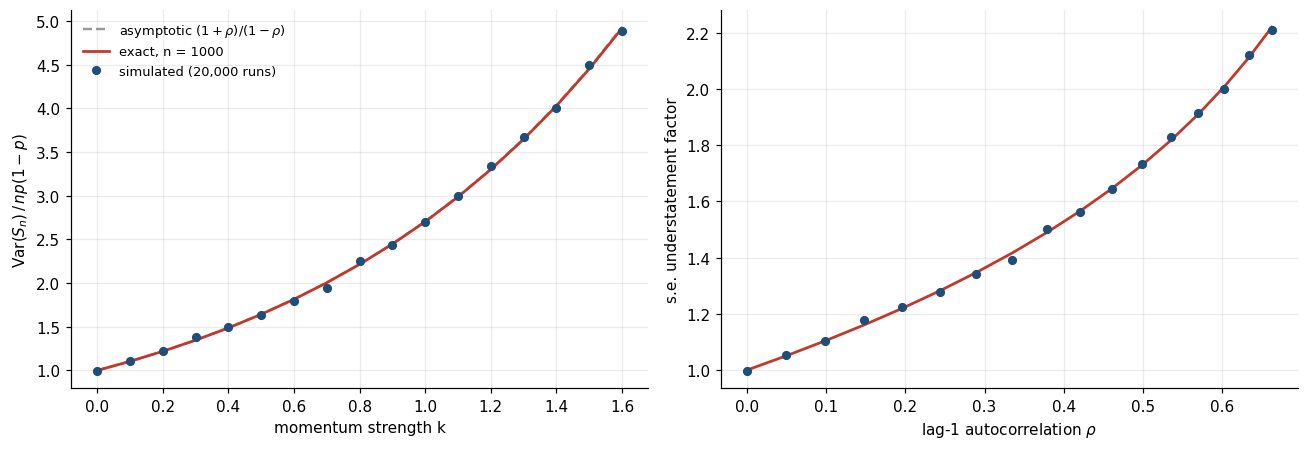

max |simulated - exact| : 0.06519696962106214


In [16]:
k_scan = np.linspace(0, 1.6, 17)
n_pts, n_seq = 1000, 20_000
emp, exact, asym, rhos = [], [], [], []
for i, k in enumerate(k_scan):
    s = TennisSimulator(p=0.55, k=float(k), seed=SEED + 500 + i)
    c = s.simulate_point_sequences(n_seq, n_pts)
    emp.append(c.var(ddof=1) / (n_pts * .55 * .45))
    exact.append(s.exact_variance(n_pts) / (n_pts * .55 * .45))
    asym.append(s.variance_inflation)
    rhos.append(s.rho)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(k_scan, asym,  color="0.6", ls="--", lw=1.6, label=r"asymptotic $(1+\rho)/(1-\rho)$")
ax1.plot(k_scan, exact, color=C1, lw=1.8, label=f"exact, n = {n_pts}")
ax1.plot(k_scan, emp, "o", color=C0, ms=5, label=f"simulated ({n_seq:,} runs)")
ax1.set_xlabel("momentum strength k"); ax1.set_ylabel(r"Var$(S_n)\,/\,np(1-p)$")
ax1.legend(fontsize=8.5)

ax2.plot(rhos, np.sqrt(np.array(asym)), color=C1, lw=1.8)
ax2.plot(rhos, np.sqrt(np.array(emp)), "o", color=C0, ms=5)
ax2.set_xlabel(r"lag-1 autocorrelation $\rho$")
ax2.set_ylabel("s.e. understatement factor")
plt.tight_layout(); plt.show()

print("max |simulated - exact| :", np.max(np.abs(np.array(emp) - np.array(exact))))

Simulation sits on the closed form. Two things worth noticing:

- The exact finite-$n$ variance approaches the asymptotic factor **from below**, because the
  covariance sum $\sum_{h}(n-h)\rho^h$ is truncated at $n$. For $\rho$ close to 1 you need an
  enormous $n$ before the asymptotic factor is even the right answer — which is another way
  of saying that near-unit-root dependence makes asymptotics a fantasy.
- $\sqrt{(1+\rho)/(1-\rho)}$ has a vertical asymptote at $\rho=1$. There is no continuity of
  consequences here: $\rho = 0.9$ gives error bars too small by a factor of 4.4, $\rho=0.99$
  by a factor of 14.

---
## Part 3 — The visible signature: runs

Correlation is hard to see in a histogram and easy to see in a *path*. The run-length
distribution is the natural diagnostic — and it is what a commentator is (badly) responding
to when he says a player is "on fire".

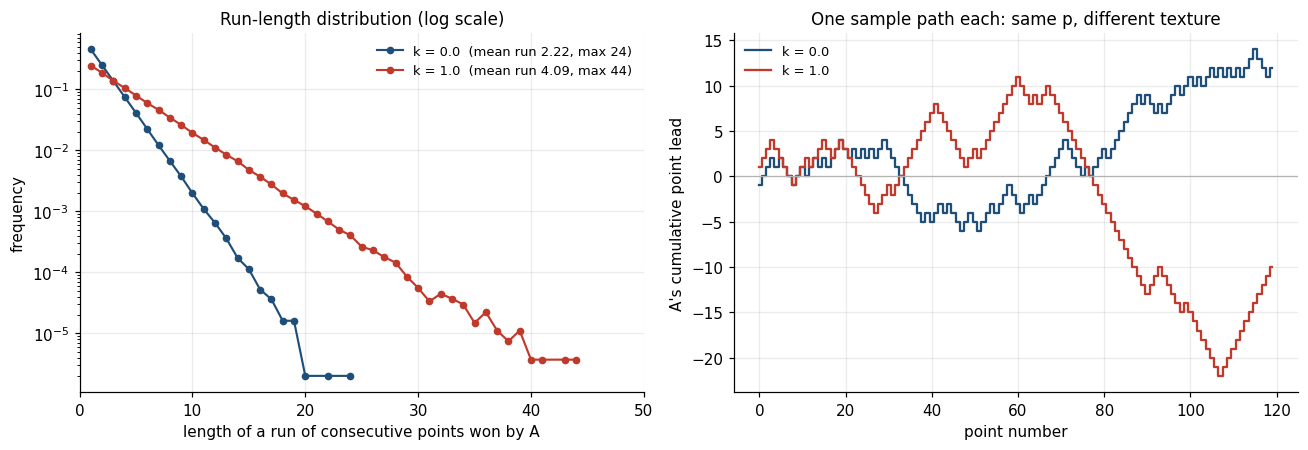

In [17]:
n_pts, n_seq = 500, 4_000
paths = {}
for i, k in enumerate([0.0, 1.0]):
    s = TennisSimulator(p=0.55, k=k, seed=SEED + 900 + i)
    _, pth = s.simulate_point_sequences(n_seq, n_pts, return_paths=True)
    paths[k] = pth

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

for k, col in [(0.0, C0), (1.0, C1)]:
    rl = np.concatenate([run_lengths(paths[k][j]) for j in range(n_seq)])
    vals, cts = np.unique(rl, return_counts=True)
    ax1.plot(vals, cts / cts.sum(), "o-", color=col, ms=4, lw=1.4,
             label=f"k = {k}  (mean run {rl.mean():.2f}, max {rl.max()})")
ax1.set_yscale("log"); ax1.set_xlim(0, 50)
ax1.set_xlabel("length of a run of consecutive points won by A")
ax1.set_ylabel("frequency"); ax1.set_title("Run-length distribution (log scale)")
ax1.legend(fontsize=8.5)

for k, col in [(0.0, C0), (1.0, C1)]:
    ax2.step(np.arange(120), np.cumsum(2 * paths[k][0][:120].astype(int) - 1),
             where="mid", color=col, lw=1.5, label=f"k = {k}")
ax2.axhline(0, color="0.7", lw=.8)
ax2.set_xlabel("point number"); ax2.set_ylabel("A's cumulative point lead")
ax2.set_title("One sample path each: same p, different texture")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

Both series have the same 55% mean. The correlated one produces streaks that an observer
would confidently narrate as momentum, confidence, or "he's found his rhythm" — and here,
uniquely, we know for certain that the narrative is right, because we wrote the generator.

The wider point cuts the other way too: in real data, streaks of this magnitude are *also*
produced by pure independence far more often than intuition allows. The run-length tail for
$k=0$ is not empty. Distinguishing the two requires non-trivial sample sizes. Sadly, we do not 
alwys have acces to these. 

---
## Part 4 — Do we get fat tails? Not from the short-range correlation alone

An order-1 Markov chain with $|\rho| < 1$ is geometrically ergodic. It satisfies a CLT.
The standardised sum converges to a Gaussian — just with the *long-run* variance
$\sigma^2_{\text{LR}} = p(1-p)\frac{1+\rho}{1-\rho}$ rather than $p(1-p)$. So if we
standardise correctly, normality returns; and excess kurtosis decays to zero as $n$ grows.

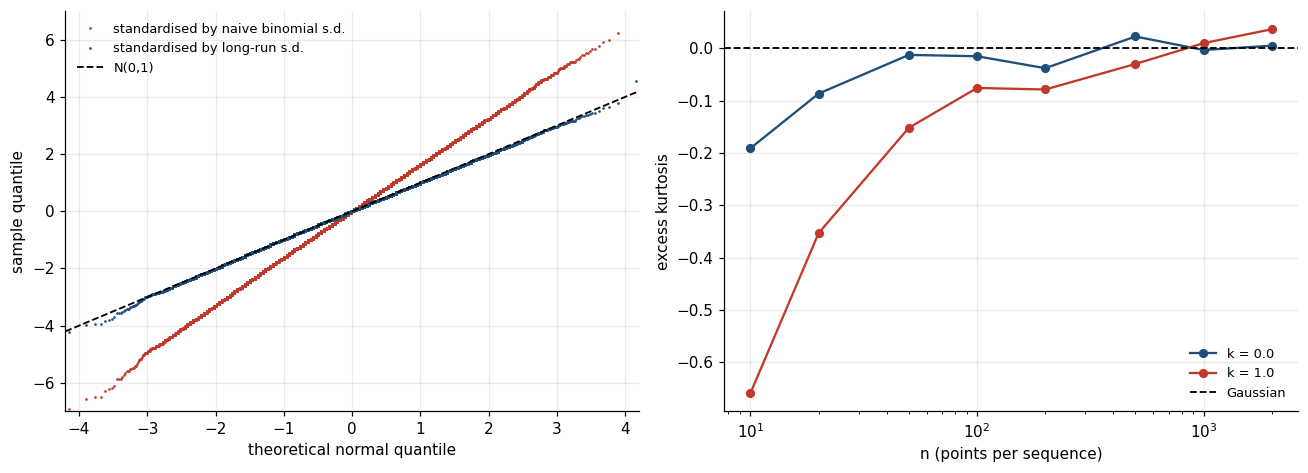

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

# QQ plot at n = 1000, correlated, both standardisations
s = TennisSimulator(p=0.55, k=1.0, seed=SEED + 77)
c = s.simulate_point_sequences(30_000, 1000)
q = (np.arange(1, len(c) + 1) - .5) / len(c)
zt = norm_ppf(q)
naive = np.sort((c - 550) / np.sqrt(1000 * .55 * .45))
correct = np.sort((c - c.mean()) / np.sqrt(s.exact_variance(1000)))
ax1.plot(zt, naive,   ".", ms=1.5, color=C1, label="standardised by naive binomial s.d.")
ax1.plot(zt, correct, ".", ms=1.5, color=C0, label="standardised by long-run s.d.")
ax1.plot([-4.2, 4.2], [-4.2, 4.2], "k--", lw=1.2, label="N(0,1)")
ax1.set_xlim(-4.2, 4.2); ax1.set_ylim(-7, 7)
ax1.set_xlabel("theoretical normal quantile"); ax1.set_ylabel("sample quantile")
ax1.legend(fontsize=8.5, loc="upper left")

# excess kurtosis vs n
ns = [10, 20, 50, 100, 200, 500, 1000, 2000]
for k, col in [(0.0, C0), (1.0, C1)]:
    ex = []
    for i, n in enumerate(ns):
        ss = TennisSimulator(p=0.55, k=k, seed=SEED + 1000 + i)
        cc = ss.simulate_point_sequences(60_000, n).astype(float)
        z = (cc - cc.mean()) / cc.std(ddof=1)
        ex.append(np.mean(z**4) - 3)
    ax2.plot(ns, ex, "o-", color=col, ms=5, lw=1.5, label=f"k = {k}")
ax2.axhline(0, color="k", ls="--", lw=1.2, label="Gaussian")
ax2.set_xscale("log"); ax2.set_xlabel("n (points per sequence)")
ax2.set_ylabel("excess kurtosis")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

- Standardised by the *correct* long-run variance, the correlated sum is Gaussian to the eye
  by $n=1000$. Excess kurtosis converges to zero for both $k=0$ and $k=1$.
- Standardised by the variance you would have *assumed*, the same data looks wildly
  fat-tailed — the red cloud fans away from the diagonal.

So "fat tails" here is not a property of the data-generating process. It is an artefact of
using the wrong scale. That is a maybe even a more insidious failure than genuine fat tails,
because every normality test one could run on correctly-standardised residuals will pass,
and they will therefore conclude their model to be fine while being systematically overconfident.
Again, that is how one looses money.

Genuine, non-vanishing tail risk requires something stronger: $\rho \to 1$ (long memory,
where the mixing rate loses the race against $n$), or strong randomness in
$p$ itself. Which is where we go next.

---
## Part 5 — The $\sqrt{n}$ machinery, and what it costs

The rate is still $n^{-1/2}$. The constant is not. This is the practical statement of
effective sample size.

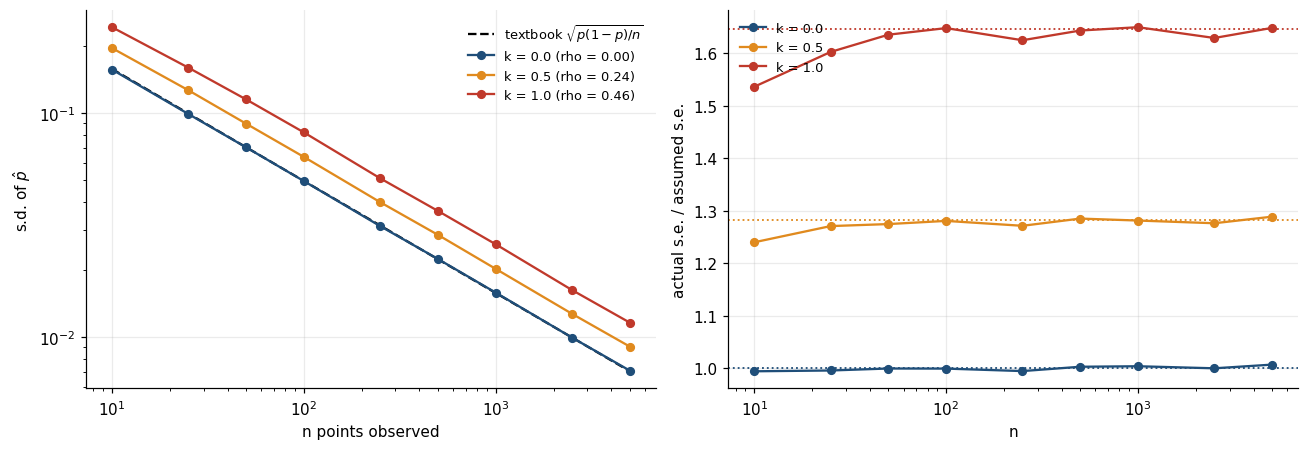

k,rho,n_eff / n,points needed to match k=0 at n=1000
0.0,0.000,1.000,"1,000"
0.5,0.243,0.608,"1,644"
1.0,0.460,0.369,"2,707"


In [19]:
ns = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
res = {}
for k in [0.0, 0.5, 1.0]:
    sds = []
    for i, n in enumerate(ns):
        s = TennisSimulator(p=0.55, k=k, seed=SEED + 2000 + i)
        c = s.simulate_point_sequences(30_000, n)
        sds.append((c / n).std(ddof=1))
    res[k] = np.array(sds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ref = np.sqrt(.55 * .45 / np.array(ns))
ax1.loglog(ns, ref, "k--", lw=1.5, label=r"textbook $\sqrt{p(1-p)/n}$")
for k, col in [(0.0, C0), (0.5, C2), (1.0, C1)]:
    ax1.loglog(ns, res[k], "o-", color=col, ms=5, lw=1.5,
               label=f"k = {k} (rho = {TennisSimulator(p=.55,k=k).rho:.2f})")
ax1.set_xlabel("n points observed"); ax1.set_ylabel(r"s.d. of $\hat p$")
ax1.legend(fontsize=8.5)

for k, col in [(0.0, C0), (0.5, C2), (1.0, C1)]:
    ax2.semilogx(ns, res[k] / ref, "o-", color=col, ms=5, lw=1.5, label=f"k = {k}")
    ax2.axhline(np.sqrt(TennisSimulator(p=.55, k=k).variance_inflation),
                color=col, ls=":", lw=1.2)
ax2.set_xlabel("n"); ax2.set_ylabel("actual s.e. / assumed s.e.")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

tab = pd.DataFrame({
    "k": [0.0, 0.5, 1.0],
    "rho": [TennisSimulator(p=.55, k=k).rho for k in (0., .5, 1.)],
    "n_eff / n": [TennisSimulator(p=.55, k=k).effective_sample_size_ratio for k in (0., .5, 1.)],
})
tab["points needed to match k=0 at n=1000"] = 1000 / tab["n_eff / n"]
display(tab.style.format({"k": "{:.1f}", "rho": "{:.3f}", "n_eff / n": "{:.3f}",
                          "points needed to match k=0 at n=1000": "{:,.0f}"})
        .hide(axis="index"))

To learn as much about $p$ from a momentum-driven player as from a memoryless one, you need
**2,700 points instead of 1,000**. A best-of-3 match contains roughly 150-250 points. So even
in the benign i.i.d. world, a *single match* tells you almost nothing about $p$; with
momentum it tells you about a third of almost nothing.

Now recall Part 1: whatever one might have learned about $p$ gets multiplied by ten on its way to
the match-win probability.

---
## Part 6 — Correlation at the match level

The barriers and the correlation now interact. Prediction before looking: extra variance in
the point share gives the underdog more chances to cross a barrier, so momentum should drag
$\mathbb{P}(\text{favourite wins})$ *toward 50%*. Momentum helps the weaker player.

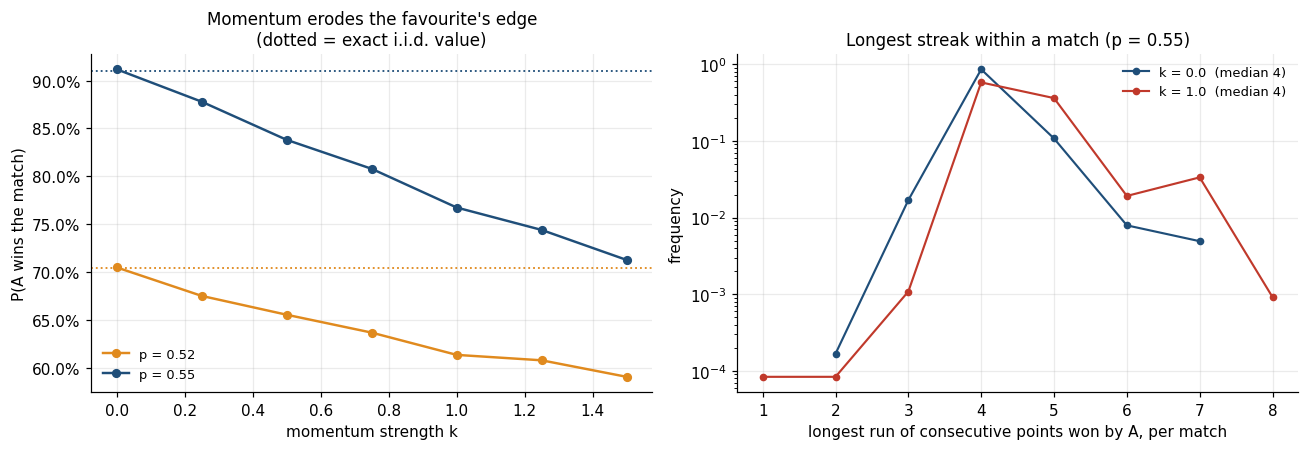

k,P(win) at p=0.52,P(win) at p=0.55,edge lost at p=0.55 (pp)
0.00,0.7048,0.9117,+0.00
0.25,0.6751,0.8779,+3.38
0.50,0.6554,0.8381,+7.37
0.75,0.6368,0.8078,+10.39
1.00,0.6135,0.7674,+14.43
1.25,0.6078,0.7440,+16.77
1.50,0.5906,0.7127,+19.91


In [20]:
k_list = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
N_MATCH = 12_000
out = {}
for p0 in (0.52, 0.55):
    wins, runs = [], []
    for i, k in enumerate(k_list):
        s = TennisSimulator(p=p0, k=k, seed=SEED + 3000 + i)
        d = s.simulate_matches(N_MATCH)
        wins.append(d["winner"].mean())
        runs.append(d["longest_run_a"])
    out[p0] = (np.array(wins), runs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
for p0, col in [(0.52, C2), (0.55, C0)]:
    w = out[p0][0]
    ax1.plot(k_list, w, "o-", color=col, ms=5, lw=1.6, label=f"p = {p0}")
    ax1.axhline(match_win_probability_iid(p0, 3), color=col, ls=":", lw=1.2)
ax1.set_xlabel("momentum strength k")
ax1.set_ylabel("P(A wins the match)")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_title("Momentum erodes the favourite's edge\n(dotted = exact i.i.d. value)")
ax1.legend(fontsize=8.5)

for k_idx, col in [(0, C0), (4, C1)]:
    r = out[0.55][1][k_idx]
    vals, cts = np.unique(r, return_counts=True)
    ax2.plot(vals, cts / cts.sum(), "o-", color=col, ms=4, lw=1.4,
             label=f"k = {k_list[k_idx]}  (median {np.median(r):.0f})")
ax2.set_yscale("log")
ax2.set_xlabel("longest run of consecutive points won by A, per match")
ax2.set_ylabel("frequency")
ax2.set_title("Longest streak within a match (p = 0.55)")
ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

df = pd.DataFrame({"k": k_list,
                   "P(win) at p=0.52": out[0.52][0],
                   "P(win) at p=0.55": out[0.55][0]})
df["edge lost at p=0.55 (pp)"] = (out[0.55][0][0] - out[0.55][0]) * 100
display(df.style.format({"k": "{:.2f}", "P(win) at p=0.52": "{:.4f}",
                         "P(win) at p=0.55": "{:.4f}",
                         "edge lost at p=0.55 (pp)": "{:+.2f}"}).hide(axis="index"))

Confirmed. The favourite's match-win probability falls monotonically in $k$ even though his
point-win probability is pinned at 0.55 throughout. Momentum is a variance pump, and in a
barrier-crossing game variance is worth something to whoever is behind.

To me (at least) a non-obvious consequence: **a model fitted on point-level data and
aggregated under an independence assumption will systematically overprice favourites.** The
error is not in the estimate of $p$ — that is correct. It is in the aggregation.

### Natural extensions

- **Random $p$ as a first-class feature** (the `random` mode still to be written): let
  $p_t$ follow a slow random walk or a two-state regime, rather than perturbing it between
  matches. Fatigue is a downward drift within a match; this is where genuinely non-vanishing
  tails appear.
- **Long memory**: replace the order-1 chain with a streak-length-dependent boost, where
  $\rho$ decays slowly enough that $\sum_h \rho_h$ diverges. That is the regime where the
  CLT genuinely can fail.
- **Estimation, not simulation**: given one observed match, what is the posterior over
  $(p, k)$? The answer — that it is close to uninformative — is the sharpest version of
  everything above.